In [1]:
import baltic as bt
import pandas as pd
import json
import os
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
from collections import Counter
import re
import sys

In [2]:
def plot_div_tree(mytree):
    
    plt.rcParams["font.family"] = "Arial"

    fig, ax = plt.subplots(figsize=(15, 15))

    x_attr = lambda k: k.x
    
    # color_by = lambda k: "red" if k.traits["is_reassorted"] else "black"

    mytree.plotTree(ax, x_attr=x_attr, width = 3)
    
    mytree.plotPoints(ax,
                   x_attr=x_attr,
                   size= 5,
                   # colour=color_by,
                   zorder=2,
                   marker='o'
                     )
    
    # legend_elements = [
    #     Patch(facecolor='red', edgecolor='red', label='Reassorted'),
    #     Patch(facecolor='black', edgecolor='black', label='Non-reassorted')
    # ]
    # ax.legend(handles=legend_elements, loc='lower left', fontsize=25, title_fontsize=30)


    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    ax.tick_params(axis='x',labelsize=30,size=15, width=2,color='grey')
    ax.set_xlabel("Divergence", fontsize=25)
    fig.tight_layout()
     
    # plt.savefig("plots/rea.pdf")
    plt.show()

In [3]:
# mytree = bt.loadNewick('/Users/asjaeger/Downloads/div_fullgenome_pa_dom.nwk', absoluteTime= False)
mytree = bt.loadNewick('/Users/asjaeger/Downloads/pb2_d11.nwk', absoluteTime= False)
# mytree = bt.loadNewick('/Users/asjaeger/Downloads/b33_div_cluster.nwk', absoluteTime= False)
# mytree = bt.loadNewick('/Users/asjaeger/Downloads/d11_div_jul25.nwk', absoluteTime= False)


# plot_div_tree(mytree)

In [26]:
# tree=bt.loadNewick('/Users/asjaeger/Downloads/div_fullgenome_pa_dom.nwk',absoluteTime=False,verbose=True) ## treeFile here can alternatively be a path to a local file
# tree=bt.loadNewick('/Users/asjaeger/Downloads/d11_div_jul25.nwk',absoluteTime=False,verbose=True) ## treeFile here can alternatively be a path to a local file
tree=bt.loadNewick('/Users/asjaeger/Downloads/b33_div_cluster.nwk',absoluteTime=False,verbose=True) ## treeFile here can alternatively be a path to a local file

tree

0 adding node
1 adding node
2 adding leaf (non-BEAST) A/khakicampbell/Pennsylvania/kc_com5/2023
adding branch length (43) 0.000000
46 adding node
47 adding leaf (non-BEAST) A/khakicampbell/Pennsylvania/kc_com4/2023
adding branch length (88) 0.000000
91 adding leaf (non-BEAST) A/khakicampbell/Pennsylvania/kc_com1/2023
adding branch length (132) 0.000000
adding branch length (135) 0.000000
adding branch length (138) 0.000000
141 adding node
142 adding leaf (non-BEAST) A/chickenbroiler/Pennsylvania/cb_com4/2023
adding branch length (184) 0.000150
208 adding leaf (non-BEAST) A/chickenbroiler/Pennsylvania/cb_com3/2023
adding branch length (250) 0.000150
274 adding node
275 adding leaf (non-BEAST) A/khakicampbell/Pennsylvania/kc_com7/2023
adding branch length (316) 0.000000
319 adding node
320 adding node
321 adding leaf (non-BEAST) A/chickenbroiler/Pennsylvania/cb_com1/2023
adding branch length (363) 0.000000
366 adding leaf (non-BEAST) A/khakicampbell/Pennsylvania/kc_com3/2023
adding branc

In [33]:
def plot_div_tree(mytree):
    
    plt.rcParams["font.family"] = "Arial"

    # Ensure y positions exist
    mytree.traverse_tree()
    mytree.sortBranches()

    fig, ax = plt.subplots(figsize=(15, 15))

    x_attr = lambda k: k.x
    y_attr = lambda k: k.y

    # Plot branches
    mytree.plotTree(
        ax,
        x_attr=x_attr,
        y_attr=y_attr,
        width=3
    )

    # Plot points (for each node or leaf)
    mytree.plotPoints(
        ax,
        x_attr=x_attr,
        y_attr=y_attr,
        size=75,
        marker='o',
        zorder=3
    )

    # Cleaned-up axis styling
    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    ax.tick_params(axis='x', labelsize=30, size=15, width=2, color='grey')
    ax.set_xlabel("Divergence", fontsize=25)

    fig.tight_layout()
    plt.show()


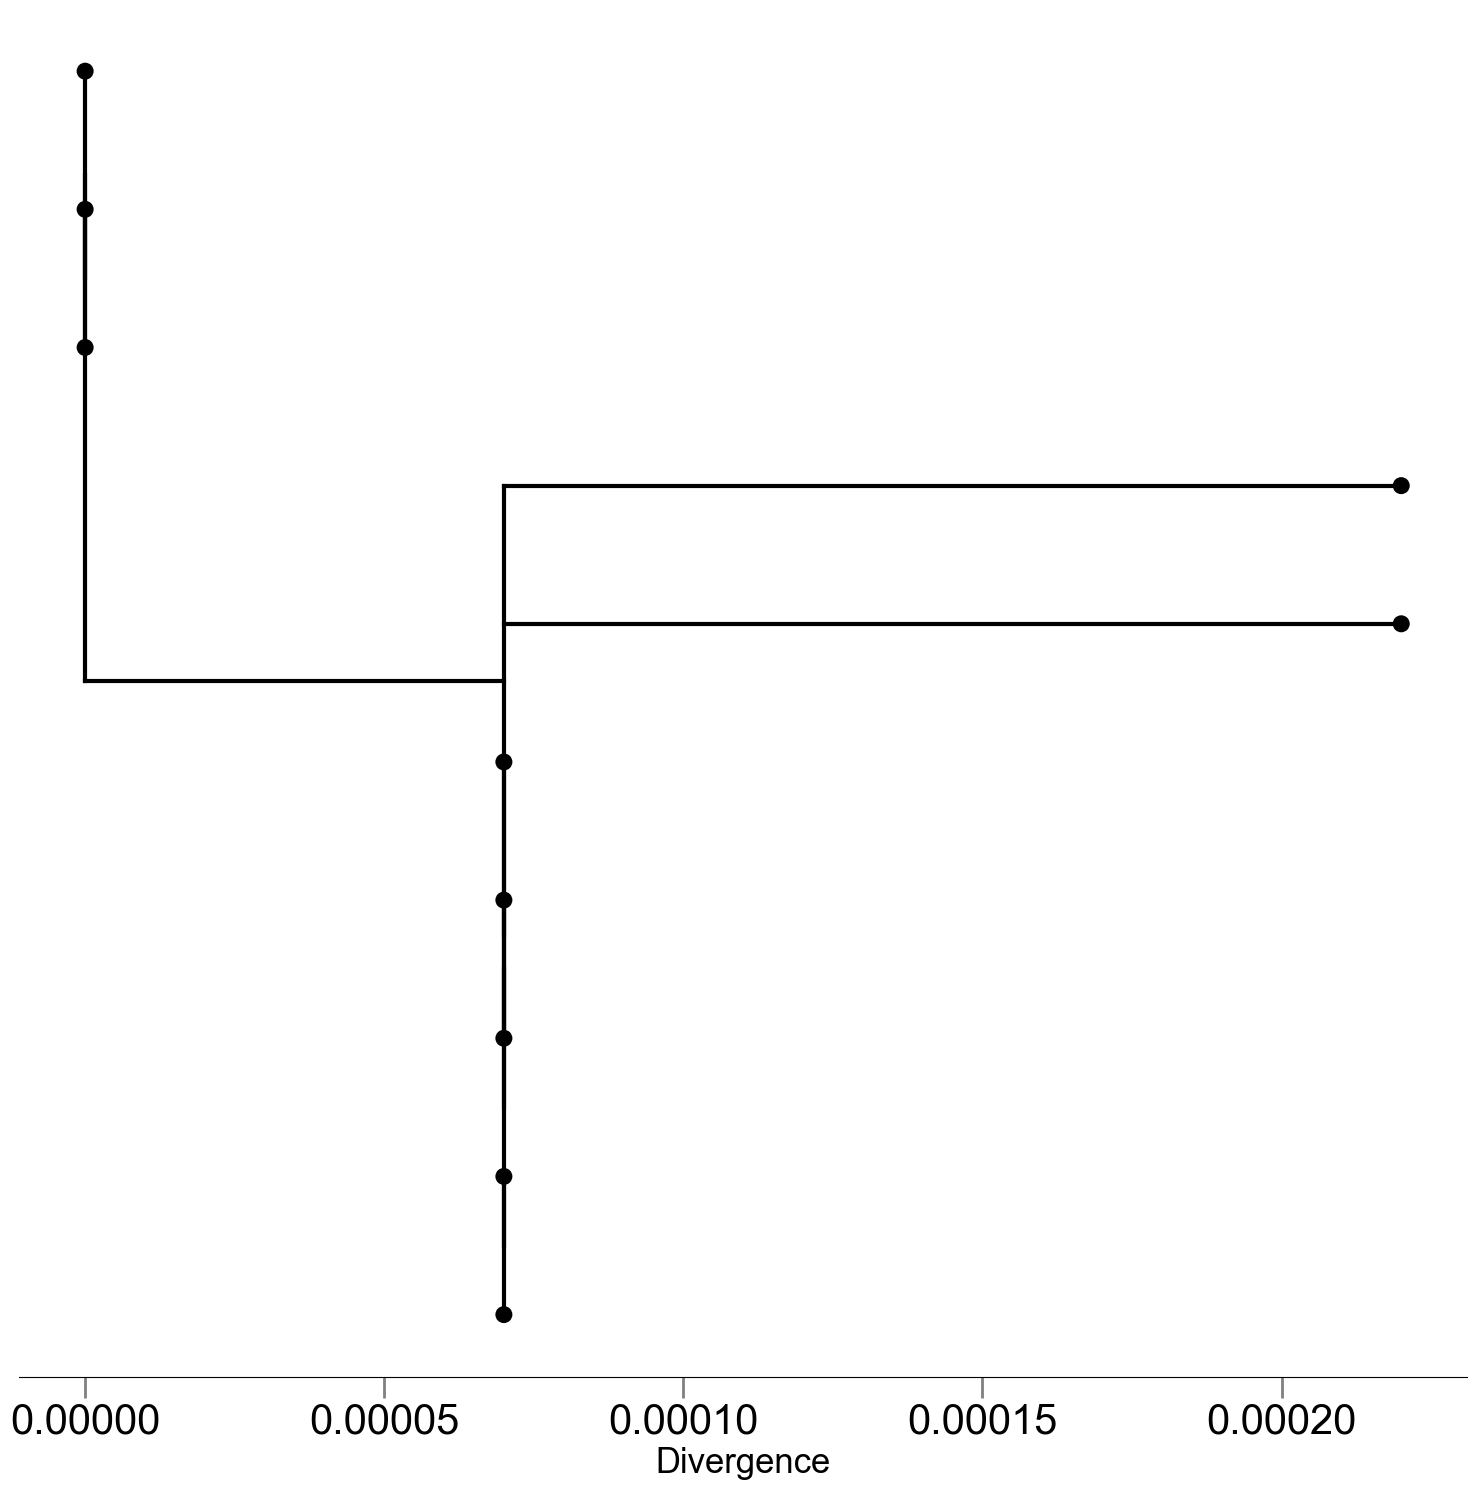

In [34]:
plot_div_tree(mytree)

In [4]:
def plot_div_tree_branch(nexustree):
    
    plt.rcParams["font.family"] = "Arial"

    # Ensure y positions exist
    mytree.traverse_tree()
    mytree.sortBranches()

    fig, ax = plt.subplots(figsize=(15, 15))

    x_attr = lambda k: k.x
    y_attr = lambda k: k.y
    c_func=lambda k: cmap(k.traits['posterior']) if k.is_node() else cmap(1.0) ## colour branches based on posterior probability
  

    # Plot branches
    mytree.plotTree(
        ax,
        x_attr=x_attr,
        y_attr=y_attr,
        width=3
    )

    # Plot points (for each node or leaf)
    mytree.plotPoints(
        ax,
        x_attr=x_attr,
        y_attr=y_attr,
        size=75,
        marker='o',
        zorder=3
    )

    # Cleaned-up axis styling
    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    ax.tick_params(axis='x', labelsize=30, size=15, width=2, color='grey')
    ax.set_xlabel("Divergence", fontsize=25)

    fig.tight_layout()
    plt.show()


In [5]:
tips_to_label = ["a/turkey/il/25009532001original/2025",
"a/turkey/il/25009630001original/2025",
"a/turkey/il/25009630002original/2025",
"a/turkey/il/25009532002original/2025",
"a/turkey/il/25008583001original/2025",
"a/turkey/il/25008583002original/2025",
"a/chicken/nv/25005483001original/2025",
"a/guineafowl/ok/25009018002original/2025",
"a/guineafowl/ok/25009018001original/2025"]  # your list here

withinhosttip = [
"A/chicken/Pennsylvania/c_lbm2/2025"]  # just the one with the withinhost 701N


# highlight_color="goldenrod"
# default_color="blue"

##for b3.3 tree
# tips_to_label = ["A/chickenbroiler/Pennsylvania/cb_com1/2023",
# "A/chickenbroiler/Pennsylvania/cb_com2/2023",
# "A/chickenbroiler/Pennsylvania/cb_com3/2023",
# "A/chickenbroiler/Pennsylvania/cb_com4/2023",
# "A/khakicampbell/Pennsylvania/kc_com1/2023",
# "A/khakicampbell/Pennsylvania/kc_com3/2023",
# "A/khakicampbell/Pennsylvania/kc_com4/2023",
# "A/khakicampbell/Pennsylvania/kc_com5/2023",
# "A/khakicampbell/Pennsylvania/kc_com6/2023",
# "A/khakicampbell/Pennsylvania/kc_com7/2023",
# "A/khakicampbell/Pennsylvania/kc_com8/2023"]  # your list here


highlight_color="goldenrod"
default_color="gray"

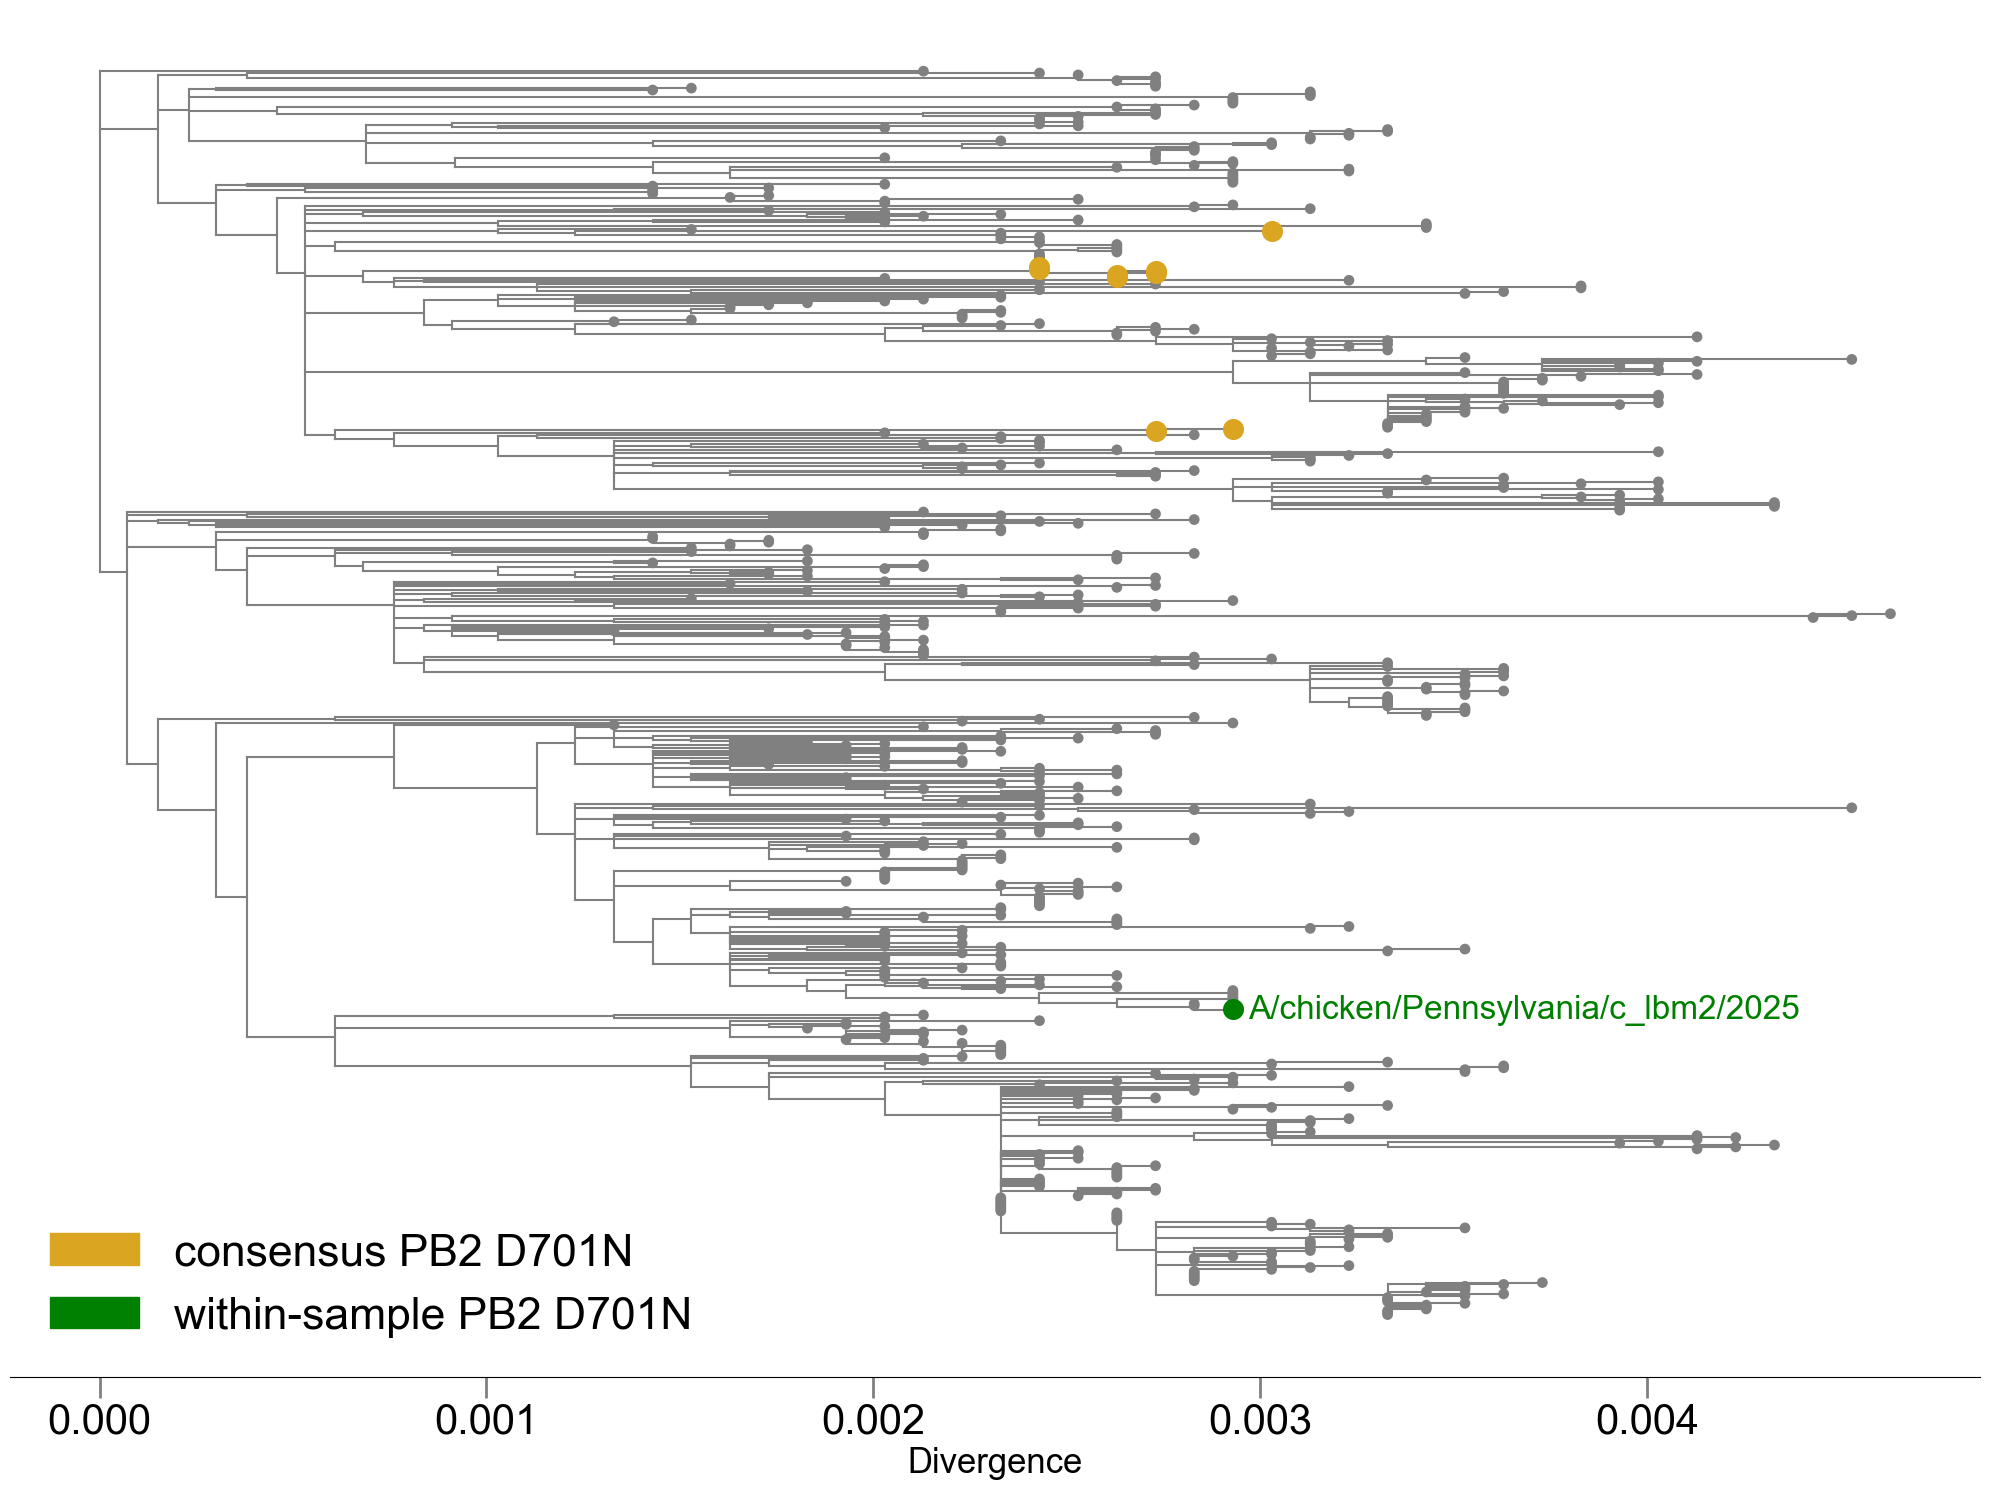

In [14]:
def plot_div_tree(mytree, tips_to_label=None):
    
    import matplotlib.pyplot as plt
    plt.rcParams["font.family"] = "Arial"

    # Ensure y positions exist
    mytree.traverse_tree()
    mytree.sortBranches()

    fig, ax = plt.subplots(figsize=(20, 15))

    x_attr = lambda k: k.x
    y_attr = lambda k: k.y

    # Plot branches
    mytree.plotTree(
        ax,
        x_attr=x_attr,
        y_attr=y_attr,
        width=1.5,
        colour=default_color
    )

    # Plot points
    mytree.plotPoints(
        ax,
        x_attr=x_attr,
        y_attr=y_attr,
        size=30,
        marker='o',
        zorder=3,
        colour=default_color,
        outline_colour=default_color
    )
    # Overlay highlighted tips on top
    if tips_to_label:
        for node in mytree.Objects:
            if node.branchType == "leaf" and node.name in tips_to_label:
                ax.scatter(
                    x_attr(node),
                    y_attr(node),
                    s=200,
                    color=highlight_color,
                    marker='o',
                    zorder=4  # higher zorder so it sits on top
                )
    # Overlay highlighted tips on top
    if withinhosttip:
        for node in mytree.Objects:
            if node.branchType == "leaf" and node.name in withinhosttip:
                ax.scatter(
                    x_attr(node),
                    y_attr(node),
                    s=200,
                    color="green",
                    marker='o',
                    zorder=4  # higher zorder so it sits on top
                )

    # --- Add tip labels ---
    for node in mytree.Objects:
        if node.branchType == "leaf":
            if withinhosttip is None or node.name in withinhosttip: ##adding this line to specify specific tip labels 
                color = highlight_color if (withinhosttip and node.name in withinhosttip) else "gray"
                ax.text(
                    x_attr(node) + 0.00004,   # small horizontal offset
                    y_attr(node),
                    node.name,
                    fontsize=24,
                    va='center',
                    color="green"
                )
    # -----------------------
    # --- Legend ---
    legend_elements = [
        Patch(facecolor="goldenrod", edgecolor="goldenrod", label="consensus PB2 D701N"),
        Patch(facecolor="green", edgecolor="green", label="within-sample PB2 D701N")
    ]
    ax.legend(handles=legend_elements, loc='lower left', fontsize=32, frameon=False)

    # Cleaned-up axis styling
    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    ax.tick_params(axis='x', labelsize=30, size=15, width=2, color='grey')
    ax.set_xlabel("Divergence", fontsize=25)

    fig.tight_layout()

    filename = "../output_plots/pb2_d701n_tree.pdf"
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)

    plt.show()
plot_div_tree(mytree, tips_to_label)

In [10]:
pwd

'/Users/asjaeger/Desktop/project_source/hpai-PA/comm-pa/comm_scripts'

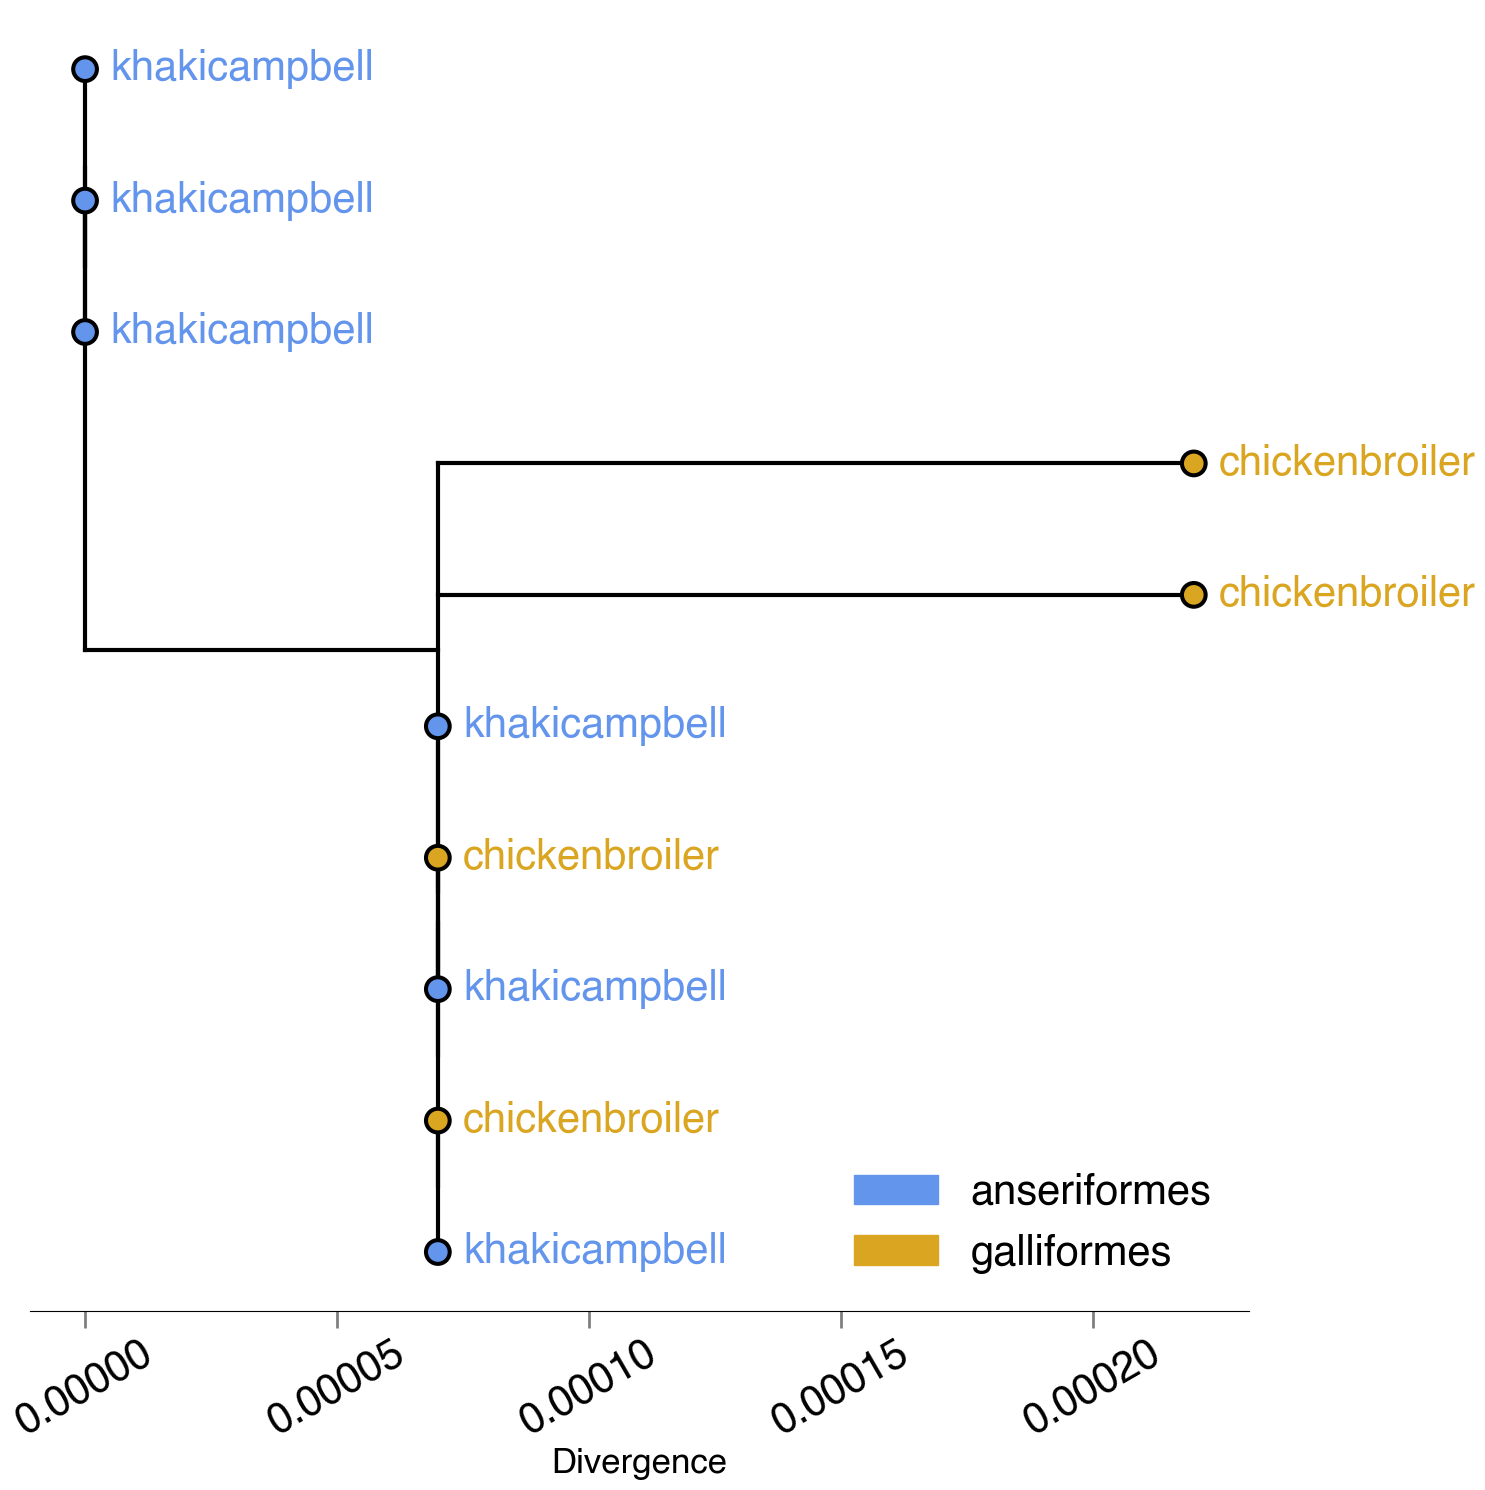

In [74]:
def plot_div_tree(mytree):
    
    import matplotlib.pyplot as plt
    plt.rcParams["font.family"] = "Helvetica"

    # Ensure y positions exist
    mytree.traverse_tree()
    mytree.sortBranches()

    fig, ax = plt.subplots(figsize=(15, 15))

    x_attr = lambda k: k.x
    y_attr = lambda k: k.y

    # # --- Color function ---
    # def tip_color(node):
    #     name = node.name.lower()
    #     if "khaki" in name:
    #         return "cornflowerblue"
    #     if "chicken" in name:
    #         return "goldenrod"
    #     return "black"
    # # ----------------------
    # --- Color function ---
    def tip_color(node):
        name = node.name.lower()
        
        if any(k in name for k in ["goose", "duck", "khaki"]):
            return "cornflowerblue"
        if any(k in name for k in ["chicken", "chukar", "guniea", "guinea"]):
            return "goldenrod"
        
        return "black"
    # ----------------------

    # --- Short name function ---
    # def short_name(node_name):
    #     # Extract 4th field (kc_com8) from A/khakicampbell/Pennsylvania/kc_com8/2023
    #     parts = node_name.split("/")
    #     if len(parts) >= 4:
    #         return parts[3]
    #     return node_name
    def short_name(node_name):
        # Extract 4th field (kc_com8) from A/khakicampbell/Pennsylvania/kc_com8/2023
        parts = node_name.split("/")
        if len(parts) >= 4:
            return parts[1]
        return node_name
    # ----------------------
    # Plot branches
    mytree.plotTree(
        ax,
        x_attr=x_attr,
        y_attr=y_attr,
        width=3
    )

    # Plot points with color by species
    mytree.plotPoints(
        ax,
        x_attr=x_attr,
        y_attr=y_attr,
        size=200,
        marker='o',
        zorder=3,
        colour=tip_color
    )

    # --- Add tip labels ---
    for node in mytree.Objects:
        if node.branchType == "leaf":
            ax.text(
                x_attr(node)+ 0.000005,
                y_attr(node),
                short_name(node.name),
                fontsize=30,
                va='center',
                ha="left",
                color=tip_color(node)   # label color matches tip color
            )
    # -----------------------

    # --- Legend ---
    legend_elements = [
        Patch(facecolor="cornflowerblue", edgecolor="cornflowerblue", label="anseriformes"),
        Patch(facecolor="goldenrod", edgecolor="goldenrod", label="galliformes")
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=30, frameon=False)
    # --------------

    # Cleaned-up axis styling
    ax.set_yticks([])
    ax.set_yticklabels([])
    [ax.spines[loc].set_visible(False) for loc in ax.spines if loc not in ['bottom']]
    ax.tick_params(axis='x', labelsize=30, size=12, rotation=30, width=2, color='grey')
    ax.set_xlabel("Divergence", fontsize=25)

    fig.tight_layout()
    # plt.savefig('../phylo_scripts_analysis/output_figs/2025-11-14-pa-comm-concat-div-tree.pdf', format='pdf')
    # plt.savefig('../phylo_scripts_analysis/output_figs/2026-02-27-pa-comm25-concat-div-tree.pdf', format='pdf')
    # filename=('../comm-pa/output_plots/div-tree-d11-jul25-hostorder.png')
    filename=('../output_plots/div-tree-b33-cluster-hostorder.png')
    plt.savefig(filename, format='png')

    plt.show()
plot_div_tree(mytree)

In [16]:
print("Tree height:", tree.treeHeight)
for k in tree.Objects[:10]:
    print(k.length)


Tree height: 0.0005000000000000004
0.0
0.0005000000000000004
0.00020000000000000573
9.999999999999593e-05
0.0
0.0
0.0
0.0
0.0
9.999999999999593e-05


In [67]:
tree.treeStats()


Tree height: 0.000500
Tree length: 0.001300

Numbers of objects in tree: 19 (8 nodes and 11 leaves)



In [63]:
tmrca_matrix = tree.allTMRCAs()
tmrca_matrix

{'A/khakicampbell/Pennsylvania/kc_com8/2023': {'A/khakicampbell/Pennsylvania/kc_com8/2023': 0.0,
  'A/khakicampbell/Pennsylvania/kc_com2/2023': None,
  'A/khakicampbell/Pennsylvania/kc_com1/2023': None,
  'A/khakicampbell/Pennsylvania/kc_com5/2023': None,
  'A/khakicampbell/Pennsylvania/kc_com4/2023': None,
  'A/chickenbroiler/Pennsylvania/cb_com3/2023': None,
  'A/chickenbroiler/Pennsylvania/cb_com4/2023': None,
  'A/khakicampbell/Pennsylvania/kc_com3/2023': None,
  'A/khakicampbell/Pennsylvania/kc_com6/2023': None,
  'A/chickenbroiler/Pennsylvania/cb_com2/2023': None,
  'A/chickenbroiler/Pennsylvania/cb_com1/2023': None},
 'A/khakicampbell/Pennsylvania/kc_com2/2023': {'A/khakicampbell/Pennsylvania/kc_com8/2023': None,
  'A/khakicampbell/Pennsylvania/kc_com2/2023': 0.0,
  'A/khakicampbell/Pennsylvania/kc_com1/2023': None,
  'A/khakicampbell/Pennsylvania/kc_com5/2023': None,
  'A/khakicampbell/Pennsylvania/kc_com4/2023': None,
  'A/chickenbroiler/Pennsylvania/cb_com3/2023': None,
  'A/